# 관리자 개입 가이드와 공정성 점검 (`05_Intervention_Guide`)

```
03_Final_Model_Tiers → 04_Second_Checkpoint → [05_Intervention_Guide] → 06_Sensitivity_Ambiguous
```

## 목적

1·2차 규칙으로 **"누구를 관리자 명단에 올릴지"**는 정했다. 이 노트북은 관리자가 명단을 받았을 때 **"왜 이 학생인가, 무엇을 해야 하는가"**에 답하고,
그 명단이 **특정 집단에 불공정하게 작동하지 않는지** 점검한다.

1. **위험 사유 코드**: 학생별 XGBoost SHAP 기여도를 관리자가 이해할 수 있는 사유(평가 미제출, 점수 낮음, 접속 부족 등)로 묶는다
2. **등급별 프로필**: 등급마다 어떤 학생이 모이는지
3. **대응 가이드**: 사유 × 등급별 권장 조치, 과목 구조별 전략
4. **관리자 업무량**: 과목·시점별 명단 규모
5. **공정성 점검**: 성별·장애·연령·IMD·학력 집단별 경고 비율, 포착률, 적중률, 보정 차이 + 인구통계 피처를 뺀 모델과 비교

## 원칙

- 운영과 같은 조건을 재현하기 위해 **holdout(2014J)을 "새 학기 배포 결과"로 보고 설명·점검**한다. 규칙은 이미 고정됐고 여기서 바꾸지 않는다.
- 사유 코드는 **예측에 대한 설명**이지 인과가 아니다. "점수 낮음" 사유는 "점수를 올리면 이탈하지 않는다"는 뜻이 아니라, 관리자가 먼저 확인할 영역을 알려준다.
- **인구통계 요인은 사유로 보여주되 대응 근거로 단독 사용하지 않는다.**

## 1. 환경 설정, 최종 모델 재현, holdout 관리자 명단

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

INK, INK_2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.facecolor': SURFACE,
                     'axes.facecolor': SURFACE, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': GRID, 'text.color': INK_2, 'axes.titlecolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'legend.frameon': False})
pd.set_option('display.width', 230)
pd.set_option('display.max_columns', 60)
TIER_NAMES = {1: '1 고위험', 2: '2 주의', 3: '3 관찰', 4: '4 일반'}


def show(frame, formats=None):
    view = frame.copy()
    for col, f in (formats or {}).items():
        if col in view.columns:
            view[col] = view[col].map(lambda v, f=f: f.format(v) if pd.notna(v) else '')
    display(view)


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()
DATA_DIR, MODEL_DIR = PROJECT_ROOT / 'CSV_files' / '통합 버전', PROJECT_ROOT / 'CSV_files' / '모델링'
spec = json.load(open(DATA_DIR / 'feature_spec_n25.json', encoding='utf-8'))
rule = json.load(open(MODEL_DIR / 'final_tier_rule_n25.json', encoding='utf-8'))
cp_students = pd.read_csv(MODEL_DIR / 'second_checkpoint_students_n25.csv')
oof = pd.read_csv(MODEL_DIR / 'dev_oof_predictions_n25.csv')
df = pd.read_csv(DATA_DIR / 'model_df_clean_n25.csv')

TARGET, NUM, CAT = spec['target'], spec['numeric_features'], spec['categorical_features']
FEATURES = NUM + CAT
GRAIN = ['id_student', 'code_module', 'code_presentation']
DEMOGRAPHIC = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
df['presentation_period'] = df['code_presentation'].str[-1]
df[TARGET] = df[TARGET].astype(int)
dev = df[df['code_presentation'] != '2014J'].reset_index(drop=True)
hold = df[df['code_presentation'] == '2014J'].reset_index(drop=True)
y_dev, y_hold = dev[TARGET].to_numpy(), hold[TARGET].to_numpy()


def _logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)


def make_xgb(num, cat, y):
    prep = ColumnTransformer([('num', 'passthrough', num), ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)], sparse_threshold=0)
    model = XGBClassifier(n_estimators=400, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
                          tree_method='hist', eval_metric='aucpr', random_state=42, n_jobs=4)
    return Pipeline([('prep', prep), ('model', model)]).set_params(**rule['params'])


final_model = make_xgb(NUM, CAT, y_dev).fit(dev[FEATURES], y_dev)
calibrator = LogisticRegression(C=1e6, max_iter=1000).fit(_logit(oof['oof_XGBoost']), y_dev)
hold_p = calibrator.predict_proba(_logit(final_model.predict_proba(hold[FEATURES])[:, 1]))[:, 1]

h = hold.merge(cp_students[cp_students['세트'] == 'holdout'][GRAIN + ['proba', 'tier', 'manager_status', 'checkpoint_day', 'enrolled_at_cp', 'missed_cp']], on=GRAIN, validate='one_to_one')
assert len(h) == len(hold) and np.allclose(h['proba'].to_numpy(), hold_p, atol=1e-6), '03 노트북 holdout 확률과 불일치'
h['final_tier'] = np.where(h['manager_status'] == '2차 승격', 2, h['tier'])
print(f'holdout {len(h):,}건(수강 단위) / 관리자 상태:', h['manager_status'].value_counts().to_dict())

holdout 9,150건(수강 단위) / 관리자 상태: {'명단 외': 5523, '25일 명단': 3130, '2차 승격': 497}


## 2. 위험 사유 코드

**방법**

1. 최종 XGBoost의 TreeSHAP(`pred_contribs`)으로 학생별·피처별 기여도(log-odds)를 구하고, 원-핫 열은 원래 피처로 합친다.
2. 피처를 관리자가 이해할 수 있는 **사유 범주**로 묶는다. 점수·제출 시점 피처의 결측은 의미가 다르므로 나눈다.

| 사유 | 피처 | 개입 가능 |
|---|---|---|
| 평가 미제출 | `n_submitted_25`, 기회가 있는데 점수·제출 시점이 결측인 경우의 `avg_score_25`·`avg_submit_delay_25` | 예 |
| 늦은 제출 | 제출자의 `avg_submit_delay_25` | 예 |
| 평가 점수 낮음 | 제출자의 `avg_score_25` | 부분 |
| 학습 접속 부족 | `total_click_25`, `active_days_25`, `distinct_resources_25`, `no_vle_activity_25` | 예 |
| 수강 학점 부담 | `studied_credits` | 부분(수강 상담) |
| 과목 구조 | `code_module`, `presentation_period`, `n_opportunity_25`, 기회가 없어 생긴 점수·시점 결측 | 과목 운영 |
| 재수강·등록 이력 | `num_of_prev_attempts`, `n_banked_25`, `date_registration` | 참고 |
| 인구통계·사회경제 | `gender`, `region`, `highest_education`, `imd_band`, `age_band`, `disability` | 참고(단독 대응 금지) |

3. 학생마다 **위험을 올린(양수) 사유 중 기여가 큰 상위 2개**를 사유 코드로 붙인다. 기여가 0.05 log-odds 미만이면 사유로 보지 않는다.

In [2]:
Xt = final_model.named_steps['prep'].transform(h[FEATURES])
contrib = final_model.named_steps['model'].get_booster().predict(xgboost.DMatrix(Xt, missing=np.nan), pred_contribs=True)
ohe = final_model.named_steps['prep'].named_transformers_['cat']
col_raw = NUM + [c for c, cats in zip(CAT, ohe.categories_) for _ in cats]
shap = pd.DataFrame(contrib[:, :-1]).T.groupby(np.array(col_raw)).sum().T[FEATURES]
margin = final_model.named_steps['model'].get_booster().predict(xgboost.DMatrix(Xt, missing=np.nan), output_margin=True)
assert np.allclose(contrib.sum(axis=1), margin, atol=1e-3)

has_opp = h['n_opportunity_25'].to_numpy() > 0
score_nan = h['avg_score_25'].isna().to_numpy()
delay_nan = h['avg_submit_delay_25'].isna().to_numpy()
R = pd.DataFrame(index=h.index)
R['평가 미제출'] = shap['n_submitted_25'] + np.where(score_nan & has_opp, shap['avg_score_25'], 0) + np.where(delay_nan & has_opp, shap['avg_submit_delay_25'], 0)
R['늦은 제출'] = np.where(~delay_nan, shap['avg_submit_delay_25'], 0)
R['평가 점수 낮음'] = np.where(~score_nan, shap['avg_score_25'], 0)
R['학습 접속 부족'] = shap[['total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25']].sum(axis=1)
R['수강 학점 부담'] = shap['studied_credits']
R['과목 구조'] = shap[['code_module', 'presentation_period', 'n_opportunity_25']].sum(axis=1) \
    + np.where(score_nan & ~has_opp, shap['avg_score_25'], 0) + np.where(delay_nan & ~has_opp, shap['avg_submit_delay_25'], 0)
R['재수강·등록 이력'] = shap[['num_of_prev_attempts', 'n_banked_25', 'date_registration']].sum(axis=1)
R['인구통계·사회경제'] = shap[DEMOGRAPHIC].sum(axis=1)
assert np.allclose(R.sum(axis=1), shap.sum(axis=1), atol=1e-6), '사유 범주가 기여도를 빠짐없이 나눠야 함'
ACTIONABLE = ['평가 미제출', '늦은 제출', '평가 점수 낮음', '학습 접속 부족', '수강 학점 부담']
MIN_CONTRIB = 0.05


def top_reasons(row, k=2):
    pos = row[row >= MIN_CONTRIB].sort_values(ascending=False)
    return list(pos.index[:k])


reasons = R.apply(top_reasons, axis=1)
h['사유1'] = reasons.map(lambda r: r[0] if len(r) > 0 else '(뚜렷한 사유 없음)')
h['사유2'] = reasons.map(lambda r: r[1] if len(r) > 1 else '')
h['개입 가능 사유 있음'] = reasons.map(lambda r: any(x in ACTIONABLE for x in r))

staff = h['final_tier'] <= 2
tab = pd.crosstab(h.loc[staff, 'manager_status'].where(h.loc[staff, 'manager_status'] == '2차 승격', h.loc[staff, 'tier'].map(TIER_NAMES)),
                  h.loc[staff, '사유1'], normalize='index')
print('관리자 명단 학생의 1순위 사유 분포 (행 = 명단 경로)')
display(tab.round(3))
any_reason = pd.concat([h.loc[staff, '사유1'], h.loc[staff & (h['사유2'] != ''), '사유2']]).value_counts() / staff.sum()
show(any_reason.rename('상위 2개 사유에 포함된 비율').to_frame(), {'상위 2개 사유에 포함된 비율': '{:.1%}'})
print(f"관리자 명단 중 개입 가능한 사유가 상위 2개에 있는 학생: {h.loc[staff, '개입 가능 사유 있음'].mean():.1%}")

관리자 명단 학생의 1순위 사유 분포 (행 = 명단 경로)


사유1,(뚜렷한 사유 없음),과목 구조,늦은 제출,수강 학점 부담,인구통계·사회경제,재수강·등록 이력,평가 미제출,평가 점수 낮음,학습 접속 부족
manager_status,,,,,,,,,
1 고위험,0.000,0.030,0.000,0.003,0.013,0.000,0.422,0.532,0.000
2 주의,0.001,0.249,0.137,0.058,0.045,0.000,0.173,0.278,0.060
2차 승격,0.024,0.205,0.326,0.109,0.165,0.018,0.000,0.000,0.153


,상위 2개 사유에 포함된 비율
과목 구조,55.6%
평가 점수 낮음,33.6%
인구통계·사회경제,21.1%
수강 학점 부담,20.8%
늦은 제출,19.4%
평가 미제출,19.1%
학습 접속 부족,12.1%
재수강·등록 이력,6.3%
(뚜렷한 사유 없음),0.4%


관리자 명단 중 개입 가능한 사유가 상위 2개에 있는 학생: 91.2%


**해석 — 관리자 명단(holdout 3,627명)의 위험 사유**

- **91.2%가 개입 가능한 사유를 상위 2개 안에 갖는다.** 관리자가 "무엇부터 확인할지"를 대부분의 학생에서 제시할 수 있다.
- **명단 경로별로 사유가 다르다.**
  - **고위험**: 1순위가 평가 점수 낮음(53.2%) 또는 평가 미제출(42.2%)로 거의 전부 평가 행동이다.
  - **주의(25일)**: 평가 점수 낮음 27.8%, 과목 구조 24.9%, 평가 미제출 17.3%, 늦은 제출 13.7%로 분산된다.
  - **2차 승격**: 25일 시점 사유는 늦은 제출 32.6%, 과목 구조 20.5%, 인구통계 16.5%, 접속 부족 15.3%다.
    이들은 25일에 뚜렷한 평가 문제가 없었고 **이후 평가를 안 내서** 명단에 올랐으므로, 관리자에게는 "체크포인트 미제출"을 1순위 사유로 함께 전달해야 한다.
- 상위 2개 사유 전체로 보면 **과목 구조가 55.6%로 가장 흔하다.** 과목 기준 이탈률이 높은 CCC·DDD·FFF 학생에게 공통으로 붙는 사유라, 학생 개인 대응보다 **과목 운영 차원의 대응**이 필요하다.

**사유별 실제 이탈률 (1순위 기준)**

| 사유 | 학생 | 실제 이탈률 | 평균 보정 확률 |
|---|---:|---:|---:|
| 평가 미제출 | 692 | **41.2%** | 38.2% |
| 수강 학점 부담 | 201 | 33.8% | 24.1% |
| 인구통계·사회경제 | 204 | 32.4% | 21.5% |
| 늦은 제출 | 508 | 31.9% | 21.8% |
| 학습 접속 부족 | 228 | 27.2% | 20.2% |
| 평가 점수 낮음 | 1,024 | 26.2% | 38.0% |
| 과목 구조 | 747 | 23.4% | 25.4% |

- **평가 미제출 사유가 가장 확실한 위험 신호**다(10명 중 4명 이탈).
- **평가 점수 낮음은 예측(38.0%)보다 실제(26.2%)가 낮다.** 이 사유 학생 1,024명 중 680명(66%)이 BBB(가중치 0 평가의 낮은 점수)이고, BBB 명단 학생의 84%가 이 사유를 1순위로 받는다. BBB 과대 표시 한계가 사유 코드에서도 드러난다.

**과목별 1순위 사유**: BBB 점수 낮음 84% / DDD 과목 구조 59% / EEE 접속 부족 68% / CCC 늦은 제출 46% / FFF 과목 구조 38%·미제출 35% / GGG 인구통계 56%·접속 부족 33% / AAA 미제출 33%.
**과목마다 관리자가 확인할 첫 번째 영역이 다르다**는 정량 근거다.

### 2.1 사유별 실제 이탈률과 과목별 사유 구성

사유 코드가 관리자에게 의미가 있으려면 **사유별로 실제 위험이 달라야** 하고, **과목마다 주요 사유가 다르면** 과목별 대응 전략이 필요하다.

In [3]:
reason_rate = h[staff].groupby('사유1').agg(학생=('사유1', 'size'), 실제_이탈률=(TARGET, 'mean'), 평균_보정확률=('proba', 'mean')).sort_values('학생', ascending=False)
show(reason_rate, {'학생': '{:,}', '실제_이탈률': '{:.1%}', '평균_보정확률': '{:.1%}'})
mod_reason = pd.crosstab(h.loc[staff, 'code_module'], h.loc[staff, '사유1'], normalize='index')
print('과목별 관리자 명단의 1순위 사유 구성')
show(mod_reason, {c: '{:.0%}' for c in mod_reason.columns})

example = h[staff].sort_values('proba', ascending=False).groupby('사유1').head(1)[GRAIN + ['final_tier', 'manager_status', 'proba', '사유1', '사유2', 'avg_score_25', 'avg_submit_delay_25', 'n_opportunity_25', 'n_submitted_25', 'active_days_25', 'studied_credits']]
print('사유별 대표 학생 예시(보정 확률이 가장 높은 학생, 식별자는 예시용)')
show(example, {'proba': '{:.1%}'})

,학생,실제_이탈률,평균_보정확률
사유1,,,
평가 점수 낮음,"1,024",26.2%,38.0%
과목 구조,747,23.4%,25.4%
평가 미제출,692,41.2%,38.2%
늦은 제출,508,31.9%,21.8%
학습 접속 부족,228,27.2%,20.2%
인구통계·사회경제,204,32.4%,21.5%
수강 학점 부담,201,33.8%,24.1%
(뚜렷한 사유 없음),14,42.9%,13.6%
재수강·등록 이력,9,55.6%,12.9%


과목별 관리자 명단의 1순위 사유 구성


사유1,(뚜렷한 사유 없음),과목 구조,늦은 제출,수강 학점 부담,인구통계·사회경제,재수강·등록 이력,평가 미제출,평가 점수 낮음,학습 접속 부족
code_module,,,,,,,,,
AAA,5%,0%,17%,19%,4%,0%,33%,18%,4%
BBB,0%,0%,0%,1%,1%,0%,14%,84%,0%
CCC,0%,7%,46%,4%,3%,0%,17%,22%,1%
DDD,0%,59%,0%,4%,4%,0%,17%,11%,4%
EEE,2%,0%,0%,22%,5%,3%,0%,0%,68%
FFF,0%,38%,0%,9%,12%,0%,35%,2%,4%
GGG,3%,0%,0%,6%,56%,3%,0%,0%,33%


사유별 대표 학생 예시(보정 확률이 가장 높은 학생, 식별자는 예시용)


,id_student,code_module,code_presentation,final_tier,manager_status,proba,사유1,사유2,avg_score_25,avg_submit_delay_25,n_opportunity_25,n_submitted_25,active_days_25,studied_credits
3144,610622,CCC,2014J,1,25일 명단,70.7%,평가 점수 낮음,수강 학점 부담,0.0,3.0,1.0,1.0,10.0,210
4869,641557,DDD,2014J,1,25일 명단,67.9%,평가 미제출,과목 구조,NaN,NaN,1.0,0.0,3.0,210
5234,683487,DDD,2014J,1,25일 명단,60.5%,과목 구조,인구통계·사회경제,50.0,4.0,1.0,1.0,11.0,180
7974,682695,FFF,2014J,1,25일 명단,44.3%,인구통계·사회경제,수강 학점 부담,72.0,-1.0,1.0,1.0,18.0,150
4915,645512,DDD,2014J,1,25일 명단,41.6%,수강 학점 부담,과목 구조,55.0,-1.0,1.0,1.0,7.0,330
3347,631880,CCC,2014J,2,25일 명단,34.8%,늦은 제출,과목 구조,56.0,3.0,1.0,1.0,9.0,90
6169,653608,EEE,2014J,2,25일 명단,34.7%,학습 접속 부족,수강 학점 부담,NaN,NaN,0.0,0.0,2.0,120
4406,487556,DDD,2014J,2,25일 명단,20.3%,(뚜렷한 사유 없음),,NaN,NaN,0.0,0.0,9.0,60
5769,555051,EEE,2014J,2,2차 승격,16.9%,재수강·등록 이력,,NaN,NaN,0.0,0.0,11.0,60


## 3. 등급별 프로필

관리자가 등급을 받았을 때 "이 등급에는 어떤 학생이 모이는가"를 한 표로 본다(holdout, 2차 승격 반영).

In [4]:
h['최종 상태'] = np.select([h['tier'] == 1, h['tier'] == 2, h['manager_status'] == '2차 승격', h['tier'] == 3], ['1 고위험', '2 주의', '2 주의(2차 승격)', '3 관찰'], '4 일반')
prof = h.groupby('최종 상태').agg(
    학생=(TARGET, 'size'), 실제_이탈률=(TARGET, 'mean'), 평균_보정확률=('proba', 'mean'),
    평가_미제출=('n_submitted_25', lambda s: ((h.loc[s.index, 'n_opportunity_25'] > 0) & (s == 0)).mean()),
    평가_기회없음=('n_opportunity_25', lambda s: (s == 0).mean()),
    평균_점수=('avg_score_25', 'mean'),
    마감후_제출=('avg_submit_delay_25', lambda s: (s > 0).mean()),
    활동일_중앙값=('active_days_25', 'median'),
    학점90이상=('studied_credits', lambda s: (s >= 90).mean()),
    재수강=('num_of_prev_attempts', lambda s: (s > 0).mean()),
    장애=('disability', lambda s: (s == 'Y').mean()),
)
show(prof, {'학생': '{:,}', '실제_이탈률': '{:.1%}', '평균_보정확률': '{:.1%}', '평가_미제출': '{:.0%}', '평가_기회없음': '{:.0%}', '평균_점수': '{:.1f}',
            '마감후_제출': '{:.0%}', '활동일_중앙값': '{:.0f}', '학점90이상': '{:.0%}', '재수강': '{:.0%}', '장애': '{:.0%}'})

,학생,실제_이탈률,평균_보정확률,평가_미제출,평가_기회없음,평균_점수,마감후_제출,활동일_중앙값,학점90이상,재수강,장애
최종 상태,,,,,,,,,,,
1 고위험,609,47.0%,46.9%,42%,0%,22.0,30%,6,64%,13%,22%
2 주의,"2,521",26.9%,29.2%,17%,9%,44.1,24%,7,37%,18%,11%
2 주의(2차 승격),497,26.6%,14.7%,0%,30%,79.6,35%,7,30%,13%,13%
3 관찰,"1,450",14.7%,15.0%,0%,26%,79.6,24%,9,40%,13%,11%
4 일반,"4,073",10.1%,8.2%,0%,28%,91.3,16%,11,22%,7%,5%


**해석 — 등급별로 모이는 학생**

| 상태 | 실제 이탈률 | 대표 특징 |
|---|---:|---|
| 1 고위험 | 47.0% | 평가 기회가 있는데 **42%가 미제출**, 제출자 평균 점수 22점, 활동일 중앙값 6일, **90학점 이상 64%**, 장애 22% |
| 2 주의(25일) | 26.9% | 미제출 17%, 평균 점수 44점, 90학점 이상 37% |
| 2 주의(2차 승격) | 26.6% | 25일엔 제출(평균 79.6점) 또는 평가 없음(30%) → **체크포인트 평가 미제출**로 승격, 25일 보정 확률은 14.7%에 불과 |
| 3 관찰 | 14.7% | 평가 기회 없음 26%, 평균 점수 79.6점 |
| 4 일반 | 10.1% | 평균 점수 91.3점, 활동일 중앙값 11일, 90학점 이상 22% |

- **2차 승격 학생은 25일 기준으로는 "괜찮아 보였던" 학생**이다(평균 점수 79.6점, 25일 확률 14.7%). 그런데 실제 이탈률은 25일 주의 등급과 같다(26.6%).
  2차 체크포인트가 **25일 모델이 볼 수 없는 위험**을 잡는다는 뜻이다.
- 고위험 학생의 64%가 90학점 이상 수강자다. **수강 부담 상담**이 고위험 대응의 핵심 축이 될 수 있다.

## 4. 관리자 업무량 — 과목·시점별 명단 규모 (holdout 학기 기준)

한 학기에 관리자가 언제, 어느 과목에서 몇 명을 확인해야 하는지 본다. 25일에 1차 명단이 한꺼번에 생기고, 2차 승격은 과목별 체크포인트일에 나뉘어 생긴다.

,재학생,고위험,주의_25일,체크포인트일,승격_2차,명단 합계,명단 비율
code_module,,,,,,,
AAA,348,3,75,54,36,114,32.8%
BBB,"1,776",110,687,54,14,811,45.7%
CCC,"2,006",209,688,32,165,"1,062",52.9%
DDD,"1,450",166,507,41,33,706,48.7%
EEE,"1,017",0,114,33,72,186,18.3%
FFF,"1,838",121,450,52,107,678,36.9%
GGG,715,0,0,61,70,70,9.8%
합계,"9,150",609,"2,521",,497,"3,627",39.6%


,일,새로 명단에 오르는 학생,과목,누적
0,25.0,"3,130",전 과목(1차),"3,130"
1,32.0,165,CCC,"3,295"
2,33.0,72,EEE,"3,367"
3,41.0,33,DDD,"3,400"
4,52.0,107,FFF,"3,507"
5,54.0,50,"AAA, BBB","3,557"
6,61.0,70,GGG,"3,627"


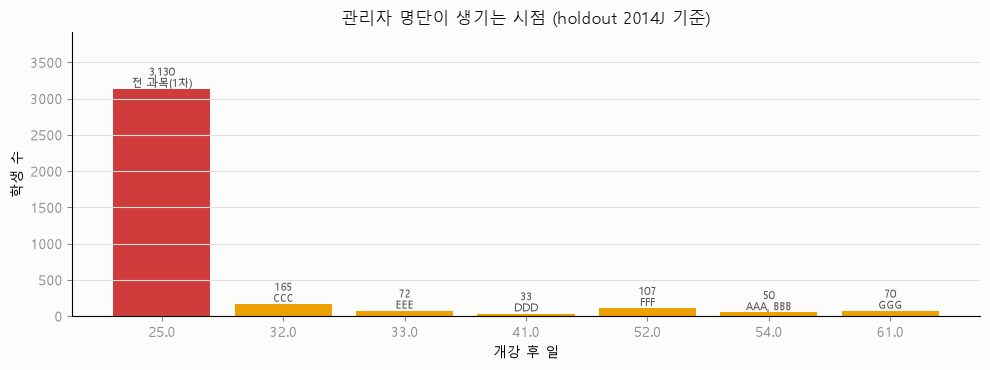

In [5]:
wl = h.groupby('code_module').agg(재학생=(TARGET, 'size'), 고위험=('tier', lambda s: (s == 1).sum()), 주의_25일=('tier', lambda s: (s == 2).sum()),
                                   체크포인트일=('checkpoint_day', 'first'), 승격_2차=('manager_status', lambda s: (s == '2차 승격').sum()))
wl['명단 합계'] = wl['고위험'] + wl['주의_25일'] + wl['승격_2차']
wl['명단 비율'] = wl['명단 합계'] / wl['재학생']
wl.loc['합계'] = [wl['재학생'].sum(), wl['고위험'].sum(), wl['주의_25일'].sum(), np.nan, wl['승격_2차'].sum(), wl['명단 합계'].sum(), wl['명단 합계'].sum() / wl['재학생'].sum()]
show(wl, {c: '{:,.0f}' for c in ['재학생', '고위험', '주의_25일', '승격_2차', '명단 합계', '체크포인트일']} | {'명단 비율': '{:.1%}'})

timeline = pd.DataFrame({'일': [25] + sorted(h['checkpoint_day'].unique().tolist())})
timeline['새로 명단에 오르는 학생'] = [int((h['tier'] <= 2).sum())] + [int(((h['checkpoint_day'] == d) & (h['manager_status'] == '2차 승격')).sum()) for d in timeline['일'][1:]]
timeline['과목'] = ['전 과목(1차)'] + [', '.join(sorted(h.loc[h['checkpoint_day'] == d, 'code_module'].unique())) for d in timeline['일'][1:]]
timeline['누적'] = timeline['새로 명단에 오르는 학생'].cumsum()
show(timeline, {'새로 명단에 오르는 학생': '{:,}', '누적': '{:,}'})

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(timeline['일'].astype(str), timeline['새로 명단에 오르는 학생'], color=['#d03b3b'] + ['#eda100'] * (len(timeline) - 1))
for i, (v, lab) in enumerate(zip(timeline['새로 명단에 오르는 학생'], timeline['과목'])):
    ax.text(i, v, f'{v:,}\n{lab}', ha='center', va='bottom', fontsize=8)
ax.set(xlabel='개강 후 일', ylabel='학생 수', title='관리자 명단이 생기는 시점 (holdout 2014J 기준)')
ax.set_ylim(0, timeline['새로 명단에 오르는 학생'].max() * 1.25)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

**해석 — 관리자 업무량 (holdout 2014J 한 학기)**

- **명단의 86%(3,130명)가 25일에 한꺼번에 생긴다.** 이후 체크포인트마다 33–165명씩 추가되어 61일까지 누적 3,627명(재학생의 39.6%)이 된다.
  → 관리자 대응 역량을 **개강 4주차에 집중 배치**해야 한다.
- **과목별 명단 비율이 크게 다르다**: CCC 52.9%, DDD 48.7%, BBB 45.7% vs GGG 9.8%, EEE 18.3%.
  과목별 튜터 1명당 담당 명단 규모가 다르므로 **인력 배분을 과목별 명단 규모에 맞춰야** 한다. BBB의 45.7%는 가중치 0 평가 학기의 과대 표시가 포함된 수치다.
- 인력이 부족하면 03 노트북의 조정 규칙(주의 하한 25%)을 적용할 수 있다. 명단 비율이 약 8%p 줄고 포착률도 약 10%p 줄어든다(03 8절).

## 5. 공정성 점검

**무엇을 보는가** (holdout, 최종 관리자 명단 = 25일 고위험·주의 + 2차 승격)

| 지표 | 의미 | 공정성 관점 |
|---|---|---|
| 명단 비율 | 집단 중 관리자 명단에 오른 비율 | 기준 이탈률이 다르면 달라지는 것이 자연스러움 |
| 포착률(Recall) | 집단의 이탈자 중 명단에 오른 비율 | **집단 간 크게 다르면 한 집단의 이탈자를 체계적으로 놓침** |
| 적중률(Precision) | 명단에 오른 학생 중 실제 이탈 비율 | 크게 다르면 한 집단에 헛연락이 몰림 |
| 보정 차이 | 평균 보정 확률 − 실제 이탈률 | 양수면 과대 표시, 음수면 과소 표시 |

성별은 과목 구성에 묶여 있으므로(심슨의 역설) **과목 안에서의 차이**도 함께 본다.

In [6]:
h['imd_group'] = np.select([h['imd_band'] == 'Unknown', h['imd_band'].isin(['0-10%', '10-20', '20-30%'])], ['Unknown', '하위 30%(빈곤)'], '상위 70%')
h['edu_group'] = np.where(h['highest_education'].isin(['No Formal quals', 'Lower Than A Level']), 'A Level 미만', 'A Level 이상')
flag = (h['final_tier'] <= 2).to_numpy()


def fairness(frame, flag_arr, col):
    rows = []
    for g, s in frame.groupby(col):
        idx = s.index.to_numpy()
        yy, ff = frame.loc[idx, TARGET].to_numpy() == 1, flag_arr[idx]
        rows.append({'변수': col, '집단': g, '학생': len(idx), '기준 이탈률': yy.mean(), '명단 비율': ff.mean(),
                     '포착률': (yy & ff).sum() / max(yy.sum(), 1), '적중률': yy[ff].mean() if ff.any() else np.nan,
                     '보정 차이': frame.loc[idx, 'proba'].mean() - yy.mean()})
    return rows


fair = pd.DataFrame(sum([fairness(h, flag, c) for c in ['gender', 'disability', 'age_band', 'imd_group', 'edu_group']], []))
show(fair.set_index(['변수', '집단']), {'학생': '{:,}', '기준 이탈률': '{:.1%}', '명단 비율': '{:.1%}', '포착률': '{:.1%}', '적중률': '{:.1%}', '보정 차이': '{:+.1%}'})

gap = fair.groupby('변수').agg(포착률_격차=('포착률', lambda s: s.max() - s.min()), 적중률_격차=('적중률', lambda s: s.max() - s.min()), 보정차이_최대절대=('보정 차이', lambda s: s.abs().max()))
show(gap, {c: '{:.1%}' for c in gap.columns})

within = []
for m, s in h.groupby('code_module'):
    for g, t in s.groupby('gender'):
        yy, ff = t[TARGET].to_numpy() == 1, flag[t.index.to_numpy()]
        within.append({'code_module': m, 'gender': g, '학생': len(t), '기준 이탈률': yy.mean(), '포착률': (yy & ff).sum() / max(yy.sum(), 1), '명단 비율': ff.mean()})
within = pd.DataFrame(within).pivot(index='code_module', columns='gender', values=['기준 이탈률', '명단 비율', '포착률'])
print('과목 안에서의 성별 비교')
show(within, {c: '{:.1%}' for c in within.columns})

학생 기준 이탈률  명단 비율    포착률    적중률  보정 차이
변수         집단                                                  
gender     F           3,848  17.5%  39.6%  60.4%  26.8%  +0.1%
           M           5,302  19.7%  39.7%  65.9%  32.7%  -1.5%
disability N           8,305  18.0%  38.0%  61.6%  29.3%  -0.5%
           Y             845  26.5%  56.2%  78.1%  36.8%  -3.3%
age_band   0-35        6,267  19.0%  41.8%  66.0%  30.0%  -0.2%
           35-55       2,796  18.4%  35.2%  59.3%  31.0%  -1.9%
           55<=           87  19.5%  26.4%  41.2%  30.4%  -6.1%
imd_group  Unknown       366  15.8%  24.6%  46.6%  30.0%  -0.9%
           상위 70%      6,101  17.9%  38.6%  61.3%  28.4%  -0.3%
           하위 30%(빈곤)  2,683  21.3%  44.0%  70.2%  34.0%  -1.9%
edu_group  A Level 미만  3,421  21.0%  47.2%  70.0%  31.1%  -1.1%
           A Level 이상  5,729  17.5%  35.1%  59.3%  29.5%  -0.6%

,포착률_격차,적중률_격차,보정차이_최대절대
변수,,,
age_band,24.8%,1.1%,6.1%
disability,16.5%,7.6%,3.3%
edu_group,10.6%,1.6%,1.1%
gender,5.5%,6.0%,1.5%
imd_group,23.7%,5.6%,1.9%


과목 안에서의 성별 비교


기준 이탈률         명단 비율           포착률       
gender           F      M      F      M      F      M
code_module                                          
AAA          15.9%  12.7%  34.4%  31.5%  58.3%  36.0%
BBB          12.6%  17.1%  46.0%  43.3%  56.9%  51.4%
CCC          29.5%  29.1%  51.7%  53.4%  75.3%  73.9%
DDD          24.2%  17.7%  50.4%  47.5%  68.6%  72.7%
EEE          18.0%  12.7%  16.4%  18.6%  47.8%  46.0%
FFF          20.5%  17.3%  34.4%  37.5%  67.6%  65.1%
GGG          12.2%  15.8%  10.2%   7.9%  20.0%  31.8%

### 5.1 인구통계 피처를 뺀 모델과 비교

인구통계·사회경제 피처 6개(`gender`, `region`, `highest_education`, `imd_band`, `age_band`, `disability`)를 빼고 같은 설정으로 학습했을 때
**성능 손실**과 **집단 간 격차 변화**를 본다. 성능 손실이 작고 격차가 줄면, 운영에서 인구통계 피처를 빼는 선택지를 검토할 근거가 된다.
이 비교는 **사후 확인**이며 최종 모델을 바꾸지 않는다(모델 변경은 별도 결정이 필요).

In [7]:
NUM_ND, CAT_ND = NUM, [c for c in CAT if c not in DEMOGRAPHIC]
splits = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(dev, y_dev, groups=dev['id_student']))
oof_nd = np.zeros(len(dev))
for tr, va in splits:
    m = make_xgb(NUM_ND, CAT_ND, y_dev[tr]).fit(dev.loc[tr, NUM_ND + CAT_ND], y_dev[tr])
    oof_nd[va] = m.predict_proba(dev.loc[va, NUM_ND + CAT_ND])[:, 1]
model_nd = make_xgb(NUM_ND, CAT_ND, y_dev).fit(dev[NUM_ND + CAT_ND], y_dev)
cal_nd = LogisticRegression(C=1e6, max_iter=1000).fit(_logit(oof_nd), y_dev)
p_nd = cal_nd.predict_proba(_logit(model_nd.predict_proba(hold[NUM_ND + CAT_ND])[:, 1]))[:, 1]

perf_nd = pd.DataFrame({
    '최종 모델(20개)': {'개발 OOF PR-AUC': average_precision_score(y_dev, oof['oof_XGBoost']), 'holdout PR-AUC': average_precision_score(y_hold, h['proba'])},
    '인구통계 제외(14개)': {'개발 OOF PR-AUC': average_precision_score(y_dev, oof_nd), 'holdout PR-AUC': average_precision_score(y_hold, p_nd)},
}).T
display(perf_nd.round(4))

# 같은 1차 등급 기준(25일 명단만)으로 집단 격차 비교
def tiers25(frame, p):
    pct = pd.Series(p, index=frame.index).groupby([frame['code_module'], frame['code_presentation']]).rank(pct=True, ascending=False, method='first').to_numpy()
    t = np.full(len(p), 4); t[(p >= rule['tier_rule']['low']) | (pct <= rule['tier_rule']['module_top'])] = 3
    t[p >= rule['tier_rule']['mid']] = 2; t[p >= rule['tier_rule']['high']] = 1
    return t


h_nd = h.assign(proba=p_nd)
flag25_full = h['tier'].to_numpy() <= 2
flag25_nd = tiers25(h, p_nd) <= 2
cmp_rows = []
for col in ['gender', 'disability', 'age_band', 'imd_group', 'edu_group']:
    a = pd.DataFrame(fairness(h, flag25_full, col)).assign(모델='최종')
    b = pd.DataFrame(fairness(h_nd, flag25_nd, col)).assign(모델='인구통계 제외')
    cmp_rows.append(pd.concat([a, b]))
cmp = pd.concat(cmp_rows)
cmp_gap = cmp.groupby(['변수', '모델']).agg(포착률_격차=('포착률', lambda s: s.max() - s.min()), 적중률_격차=('적중률', lambda s: s.max() - s.min()),
                                            명단비율_격차=('명단 비율', lambda s: s.max() - s.min())).unstack('모델')
print('25일 명단 기준 집단 간 격차: 최종 모델 vs 인구통계 제외 모델')
show(cmp_gap, {c: '{:.1%}' for c in cmp_gap.columns})
show(cmp[cmp['변수'] == 'disability'].set_index(['모델', '집단'])[['학생', '기준 이탈률', '명단 비율', '포착률', '적중률', '보정 차이']],
     {'학생': '{:,}', '기준 이탈률': '{:.1%}', '명단 비율': '{:.1%}', '포착률': '{:.1%}', '적중률': '{:.1%}', '보정 차이': '{:+.1%}'})
print(f'전체 25일 명단 포착률 — 최종 {(y_hold.astype(bool) & flag25_full).sum() / y_hold.sum():.1%} / 인구통계 제외 {(y_hold.astype(bool) & flag25_nd).sum() / y_hold.sum():.1%}')

,개발 OOF PR-AUC,holdout PR-AUC
최종 모델(20개),0.4033,0.3572
인구통계 제외(14개),0.3982,0.3495


25일 명단 기준 집단 간 격차: 최종 모델 vs 인구통계 제외 모델


포착률_격차         적중률_격차       명단비율_격차       
모델         인구통계 제외     최종 인구통계 제외    최종 인구통계 제외     최종
변수                                                    
age_band     29.0%  28.8%    2.5%  4.4%   17.2%  15.7%
disability    1.4%  14.5%    8.5%  7.7%    5.8%  15.8%
edu_group     1.0%  11.4%    3.1%  2.4%    2.3%  10.9%
gender        7.9%   6.8%    7.6%  8.0%    0.3%   0.9%
imd_group    18.7%  22.0%   10.3%  5.9%   10.0%  17.3%

학생 기준 이탈률  명단 비율    포착률    적중률  보정 차이
모델      집단                                          
최종      N   8,305  18.0%  32.8%  54.2%  29.8%  -0.5%
        Y     845  26.5%  48.5%  68.8%  37.6%  -3.3%
인구통계 제외 N   8,305  18.0%  33.8%  55.7%  29.7%  -0.4%
        Y     845  26.5%  39.6%  57.1%  38.2%  -7.5%

전체 25일 명단 포착률 — 최종 56.1% / 인구통계 제외 55.9%


**해석 — 공정성**

**1) 최종 관리자 명단의 집단별 결과**

- **확률 보정은 모든 집단에서 양호하다**(보정 차이 절대값 3.3%p 이하). 예외는 표본이 87명인 55세 이상(−6.1%p)이다. **"같은 확률이면 같은 위험"이 집단과 무관하게 성립한다.**
- **명단 비율 차이는 대부분 기준 이탈률 차이를 따른다**: 장애 있음(이탈률 26.5%) 56.2% vs 없음(18.0%) 38.0%, 학력 A Level 미만(21.0%) 47.2% vs 이상(17.5%) 35.1%, IMD 하위 30%(21.3%) 44.0% vs 상위(17.9%) 38.6%.
- **포착률 격차가 큰 집단**: 연령 55세 이상 41.2%(n=87, 이탈자 약 17명), IMD Unknown 46.6%(n=366). 둘 다 작은 집단이라 불확실성이 크다.
- **성별**: 명단 비율은 39.6% vs 39.7%로 같고, 포착률은 여성 60.4% vs 남성 65.9%다. 과목 안에서 보면 대부분 과목에서 차이가 작다
  (CCC 75.3% vs 73.9%, FFF 67.6% vs 65.1%). 표본이 작은 AAA·GGG에서만 크게 갈린다.

**2) 인구통계 피처를 뺀 모델과 비교 (사후 확인)**

| 항목 | 최종 모델 | 인구통계 제외 |
|---|---:|---:|
| 개발 OOF PR-AUC | 0.4033 | 0.3982 (−0.005) |
| holdout PR-AUC | 0.3572 | 0.3495 (−0.008) |
| 전체 25일 명단 포착률 | 56.1% | 55.9% |
| 장애 여부 포착률 격차 | 14.5%p | **1.4%p** |
| 학력 포착률 격차 | 11.4%p | **1.0%p** |
| 성별 / 연령 포착률 격차 | 6.8%p / 28.8%p | 7.9%p / 29.0%p |
| 장애 학생 포착률 / 보정 차이 | 68.8% / −3.3%p | **57.1% / −7.5%p** |

- 인구통계를 빼면 **전체 성능은 거의 같고, 장애·학력 집단의 포착률 격차는 크게 줄어든다.** 성별·연령 격차는 줄지 않는다(연령은 55세 이상 n=87의 영향).
- 그러나 **실제로 위험이 더 높은 장애 학생(이탈률 26.5%)의 위험을 더 과소 예측**하고, 이 학생들의 포착률이 68.8% → 57.1%로 떨어진다.
  이는 공정성의 두 정의가 충돌하는 전형적인 경우다.
  - **"같은 포착률"** 관점: 인구통계 제외가 유리
  - **"집단별로 정확한 위험"** 관점(보정): 최종 모델이 유리하고, 위험이 높은 집단이 지원을 더 받는다

**권고**: **최종 모델을 유지**하되, 인구통계 사유는 **지원 서비스 연계 목적**(예: 장애 학생 지원 부서 안내)으로만 쓰고, 이것만으로 개입 강도를 정하지 않는다.
어느 공정성 정의를 우선할지는 **기관의 정책 판단**이다. 이 표가 그 판단의 근거가 된다.

## 6. 결과 저장

| 파일 | 내용 |
|---|---|
| `intervention_reason_codes_holdout_n25.csv` | holdout 학생별 최종 상태, 보정 확률, 사유 1·2, 사유 범주별 기여도 |
| `fairness_check_holdout_n25.csv` | 집단별 명단 비율·포착률·적중률·보정 차이 |
| `fairness_no_demographics_comparison_n25.csv` | 인구통계 제외 모델과의 집단 격차 비교 |

In [8]:
out = h[GRAIN + [TARGET, 'proba', 'tier', 'manager_status', '최종 상태', '사유1', '사유2', '개입 가능 사유 있음']].join(R.add_prefix('기여_'))
out.to_csv(MODEL_DIR / 'intervention_reason_codes_holdout_n25.csv', index=False, encoding='utf-8-sig')
fair.to_csv(MODEL_DIR / 'fairness_check_holdout_n25.csv', index=False, encoding='utf-8-sig')
cmp.to_csv(MODEL_DIR / 'fairness_no_demographics_comparison_n25.csv', index=False, encoding='utf-8-sig')
chk = pd.read_csv(MODEL_DIR / 'intervention_reason_codes_holdout_n25.csv')
assert len(chk) == 9150 and not chk.duplicated(GRAIN).any()
print('saved', len(chk))

saved 9150


## 7. 대응 가이드와 결론

### 7.1 관리자 대응 가이드

**등급별 기본 대응**

| 상태 | 시점 | 대응 | 담당 |
|---|---|---|---|
| **1 고위험** | 25일 직후, 1주 이내 | 개별 연락(전화·면담). 사유 1·2를 먼저 확인. 수강 부담이 크면 과목 조정·휴학 옵션 안내 | 튜터 + 학사 담당 |
| **2 주의(25일)** | 25일 이후 2주 이내 | 맞춤 메시지 + 다음 평가 전 체크인. 반응 없으면 연락 | 튜터 |
| **2 주의(2차 승격)** | 체크포인트 직후 | **미제출 사유 확인 연락**, 연장·재제출 가능 여부 안내 | 튜터 |
| **3 관찰** | 체크포인트까지 | 개별 대응 없음. 체크포인트 평가 미제출 시 자동 승격 | 시스템 |
| **4 일반** | — | 개별 대응 없음 | — |
| (전원) | 평가 마감 전 | 일반 리마인더(위험도 무관) | 시스템 |

**사유별 권장 조치** (인과 검증 전 가설 — 실행 시 효과 측정 필요)

| 사유 | 관리자가 먼저 확인할 것 | 권장 조치 |
|---|---|---|
| 평가 미제출 | 제출 못 한 이유(시간·이해·기술 문제) | 연장·재제출 안내, 과제 이해 지원 |
| 늦은 제출 | 일정 관리 어려움 | 다음 마감 1주 전 체크인, 학습 계획 지원 |
| 평가 점수 낮음 | 내용 이해 부족 여부 | 튜터링·피드백 세션 연결 |
| 학습 접속 부족 | 접속 장애(기기·시간), 동기 저하 | 학습 참여 독려, 접근성 지원 |
| 수강 학점 부담 | 동시 수강 과목 수·업무 병행 | 수강 설계 상담(과목 조정·다음 학기 분산) |
| 과목 구조 | (학생 개인보다 과목 문제) | 과목 운영팀에 전달: 조기 체크포인트·초기 과제 설계 검토 |
| 인구통계·사회경제 | 지원 서비스 필요 여부 | 해당 지원 부서 연계. **이 사유만으로 개입 강도를 정하지 않음** |

### 7.2 과목 구조별 전략

| 과목 유형 | 해당 과목 | 25일 핵심 신호 | 전략 |
|---|---|---|---|
| 25일 내 평가 있음 | AAA, BBB, CCC, DDD, FFF | 평가 제출·점수·시점 | 첫 평가 전후 집중 관리, 미제출자 즉시 연락 |
| 25일 내 평가 없음, 33일 첫 평가 | EEE | 학습 접속 | 25일 접속 부족 학생 우선, 33일 체크포인트 미제출 즉시 승격 |
| 61일까지 평가 없음(가중치 0) | GGG | 약함(인구통계·접속) | 모델 신호가 약하다는 전제로 운영. 과목 운영팀에 **조기 체크포인트 도입 검토** 제안 |
| 평가 일정이 바뀐 학기 | 예: BBB 2014J(가중치 0) | 점수 의미 달라짐 | 배포 전 일정 점검, 해당 학기 점수 사유는 신중히 해석 |

### 7.3 결론

- **사유 코드**: 관리자 명단의 91%에 개입 가능한 사유를 제시할 수 있다. 가장 확실한 신호는 평가 미제출(실제 이탈률 41.2%)이다.
- **업무량**: 명단의 86%가 25일에 생기므로 **개강 4주차 인력 집중**이 필요하다. 과목별 명단 비율은 10–53%로 달라 인력 배분도 과목별로 해야 한다.
- **공정성**: 확률 보정은 집단 간 양호하다. 인구통계를 빼면 장애·학력 포착률 격차는 줄지만(성별·연령은 그대로), 위험이 높은 장애 학생을 과소 예측한다. **최종 모델을 유지하고 인구통계 사유는 지원 연계에만 쓰는 것**을 권고하며, 공정성 정의 선택은 기관 정책으로 남긴다.
- **한계**: 권장 조치는 연관 분석에서 나온 가설이다. 실제 운영에서는 조치별 효과를 측정해 가이드를 갱신해야 한다.